In [1]:


import pandas as pd

#df_raw = pd.read_csv('sample_data/EPA_SmartLocationDatabase_V3_Jan_2021_Final.csv')
df_raw = pd.read_csv('EPA_SmartLocationDatabase_V3_Jan_2021_Final.csv')

df_raw.head()

,OBJECTID,GEOID10,GEOID20,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,CSA,CSA_Name,CBSA,...,D5DRI,D5DE,D5DEI,D2A_Ranked,D2B_Ranked,D3B_Ranked,D4A_Ranked,NatWalkInd,Shape_Length,Shape_Area
0,1,4.811300e+11,4.811300e+11,48,113,7825,4,206.0,"Dallas-Fort Worth, TX-OK",19100.0,...,0.184697,0.000476,0.137707,6,14,15,17,14.000000,3110.360820,297836.0831
1,2,4.811300e+11,4.811300e+11,48,113,7825,2,206.0,"Dallas-Fort Worth, TX-OK",19100.0,...,0.323221,0.000801,0.231868,3,10,12,14,10.833333,3519.469110,484945.1466
2,3,4.811300e+11,4.811300e+11,48,113,7825,3,206.0,"Dallas-Fort Worth, TX-OK",19100.0,...,0.314628,0.000736,0.213146,1,1,7,17,8.333333,1697.091802,106705.9281
3,4,4.811300e+11,4.811300e+11,48,113,7824,1,206.0,"Dallas-Fort Worth, TX-OK",19100.0,...,0.229821,0.000708,0.205018,16,10,17,17,15.666667,2922.609204,481828.4303
4,5,4.811300e+11,4.811300e+11,48,113,7824,2,206.0,"Dallas-Fort Worth, TX-OK",19100.0,...,0.164863,0.000433,0.125296,4,7,11,14,10.166667,3731.971773,687684.7752


In [2]:
print(df_raw.shape)

(220740, 117)


In [3]:
print(df_raw.dtypes)


OBJECTID          int64
GEOID10         float64
GEOID20         float64
STATEFP           int64
COUNTYFP          int64
                 ...   
D3B_Ranked        int64
D4A_Ranked        int64
NatWalkInd      float64
Shape_Length    float64
Shape_Area      float64
Length: 117, dtype: object


In [4]:
print(df_raw.head())

   OBJECTID       GEOID10       GEOID20  STATEFP  COUNTYFP  TRACTCE  BLKGRPCE  \
0         1  4.811300e+11  4.811300e+11       48       113     7825         4   
1         2  4.811300e+11  4.811300e+11       48       113     7825         2   
2         3  4.811300e+11  4.811300e+11       48       113     7825         3   
3         4  4.811300e+11  4.811300e+11       48       113     7824         1   
4         5  4.811300e+11  4.811300e+11       48       113     7824         2   

     CSA                  CSA_Name     CBSA  ...     D5DRI      D5DE  \
0  206.0  Dallas-Fort Worth, TX-OK  19100.0  ...  0.184697  0.000476   
1  206.0  Dallas-Fort Worth, TX-OK  19100.0  ...  0.323221  0.000801   
2  206.0  Dallas-Fort Worth, TX-OK  19100.0  ...  0.314628  0.000736   
3  206.0  Dallas-Fort Worth, TX-OK  19100.0  ...  0.229821  0.000708   
4  206.0  Dallas-Fort Worth, TX-OK  19100.0  ...  0.164863  0.000433   

      D5DEI  D2A_Ranked  D2B_Ranked  D3B_Ranked  D4A_Ranked  NatWalkInd  \
0  0.

In [12]:
num_zero_or_null_d4c = df_raw[(df_raw['D4C'] == 0) | (df_raw['D4C'].isnull())].shape[0]
print(f"Number of rows where D4C is zero or null: {num_zero_or_null_d4c}")

Number of rows where D4C is zero or null: 0


In [19]:
df_clean = df_raw.copy()

# 1. Filter to GTFS-participating CBGs only
# df_clean = df_clean[df_clean['D4C'].notna() & (df_clean['D4C'] > 0)]

print(f"CBGs remaining after GTFS filter: {len(df_clean)}")
print("Total CBGs before filter:", len(df_raw))
print("Total after GTFS filter:", len(df_clean))
print("Percent retained:", len(df_clean) / len(df_raw))

# 2. Keep only relevant columns
cols_to_keep = [
    # Identifiers
    'GEOID10', 'GEOID20', 'STATEFP', 'COUNTYFP',
    'CBSA', 'CBSA_Name', 'CSA', 'CSA_Name',

    # Demographics & equity
    'TotPop', 'HH', 'P_WrkAge',
    'Pct_AO0',        # zero-car households (equity weight)
    'R_PCTLOWWAGE',   # low wage workers (equity weight)
    'Workers',

    # Employment
    'TotEmp',

    # Density (D1)
    'D1A', 'D1B', 'D1C', 'D1D',

    # Diversity (D2)
    'D2A_JPHH', 'D2B_E5MIXA', 'D2A_EPHHM',

    # Design (D3)
    'D3B',

    # Transit Access (D4)
    'D4A', 'D4C', 'D4D',

    # Destination Accessibility (D5)
    'D5AR', 'D5BR',

    # Walkability
    'NatWalkInd'
]

df_clean = df_clean[cols_to_keep]

# 3. Check missing values
print(df_clean.isnull().sum())
missing_pct = df_clean.isnull().mean().sort_values(ascending=False)
print("Top variables by missing share:")
print(missing_pct.head(10))

CBGs remaining after GTFS filter: 220740
Total CBGs before filter: 220740
Total after GTFS filter: 220740
Percent retained: 1.0
GEOID10             1
GEOID20             0
STATEFP             0
COUNTYFP            0
CBSA            17095
CBSA_Name       17095
CSA             53031
CSA_Name        53031
TotPop              0
HH                275
P_WrkAge            0
Pct_AO0             0
R_PCTLOWWAGE        0
Workers             0
TotEmp              0
D1A               271
D1B                 0
D1C                 0
D1D                 0
D2A_JPHH            0
D2B_E5MIXA          0
D2A_EPHHM           0
D3B                 0
D4A                 0
D4C                 0
D4D                 1
D5AR                0
D5BR                0
NatWalkInd          0
dtype: int64
Top variables by missing share:
CSA          0.240242
CSA_Name     0.240242
CBSA_Name    0.077444
CBSA         0.077444
HH           0.001246
D1A          0.001228
GEOID10      0.000005
D4D          0.000005
COUNTYFP     

In [20]:
# Remove CBGs with zero population or zero employment
# these will produce unreliable gap scores
df_clean = df_clean[df_clean['TotPop'] > 0]
df_clean = df_clean[df_clean['TotEmp'] > 0]

print(f"CBGs after removing zero population/employment: {len(df_clean)}")
print("Dropped due to zero pop or employment:",
      len(df_raw) - len(df_clean))

CBGs after removing zero population/employment: 215216
Dropped due to zero pop or employment: 5524


In [22]:
df_analysis = df_clean.copy()

# 1. Create target variable
df_analysis['transit_gap'] = df_analysis['D5AR'] - df_analysis['D5BR']

# 2. Create equity weight
df_analysis['equity_weight'] = (
    (df_analysis['Pct_AO0'] - df_analysis['Pct_AO0'].min()) /
    (df_analysis['Pct_AO0'].max() - df_analysis['Pct_AO0'].min()) +
    (df_analysis['R_PCTLOWWAGE'] - df_analysis['R_PCTLOWWAGE'].min()) /
    (df_analysis['R_PCTLOWWAGE'].max() - df_analysis['R_PCTLOWWAGE'].min())
) / 2

# 3. Sanity checks
print(f"Total CBGs: {len(df_analysis)}")
print(f"Transit gap stats:\n{df_analysis['transit_gap'].describe()}")
print(f"CBGs where transit outperforms auto: "
      f"{(df_analysis['transit_gap'] < 0).sum()}")

print("Correlation between D5BR and transit_gap:")
print(df_analysis[['D5BR','transit_gap']].corr())

df_analysis[['D5AR','D5BR','transit_gap']].describe()
df_analysis[['D4C','D4D','D4A']].describe()
df_analysis[['Pct_AO0','R_PCTLOWWAGE']].describe()

# 4. Save outputs
df_raw.to_csv('sld_raw.csv', index=False)
df_clean.to_csv('sld_clean.csv', index=False)
df_analysis.to_csv('sld_analysis.csv', index=False)

Total CBGs: 215216
Transit gap stats:
count    2.152160e+05
mean     5.846818e+04
std      2.921904e+05
min     -6.188433e+06
25%      3.818775e+04
50%      1.045410e+05
75%      1.299430e+05
max      8.755810e+05
Name: transit_gap, dtype: float64
CBGs where transit outperforms auto: 30457
Correlation between D5BR and transit_gap:
                 D5BR  transit_gap
D5BR         1.000000    -0.936174
transit_gap -0.936174     1.000000


count    86748.000000
mean         0.712260
std          0.562791
min          0.000013
25%          0.245082
50%          0.596193
75%          1.062887
max          2.422485
Name: transit_ratio, dtype: float64
Extreme high transit_ratio (> 3): 0
Extreme low transit_ratio (< 0.1): 10749


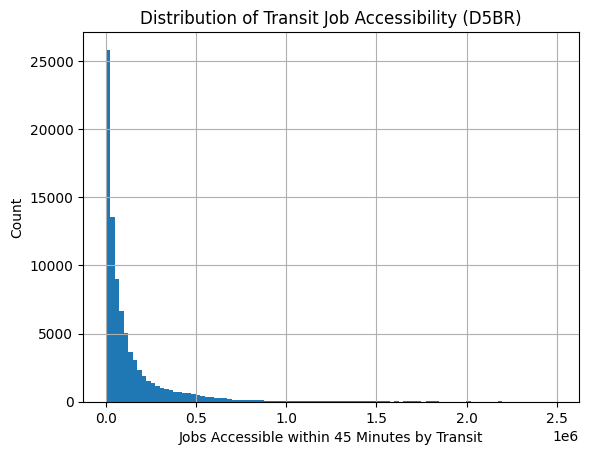

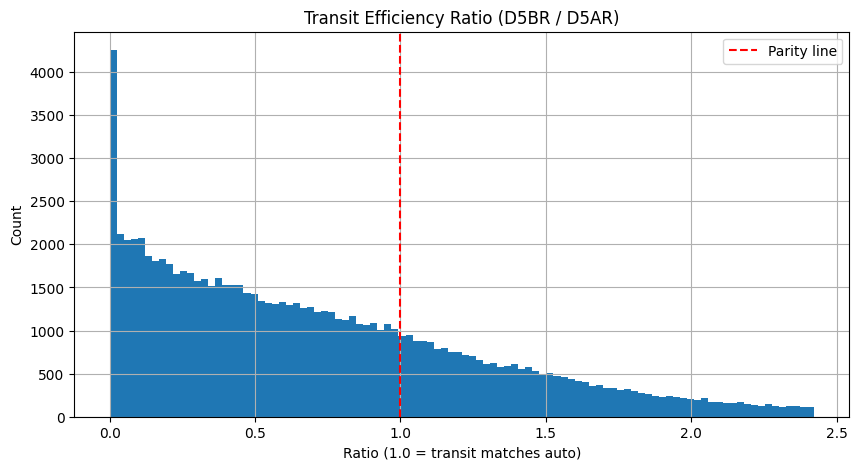

In [33]:
# Filter out invalid D5BR values and ensure D5AR is positive before calculating transit_ratio
# D5BR = -99999 is a sentinel for invalid data, so remove these rows.
# D5AR must be > 0 to calculate a meaningful ratio and avoid division by zero.
df_analysis = df_analysis[(df_analysis['D5BR'] >= 0) & (df_analysis['D5AR'] > 0)].copy()

#  transit efficiency ratio
df_analysis['transit_ratio'] = df_analysis['D5BR'] / df_analysis['D5AR']

print(df_analysis['transit_ratio'].describe())

print("Extreme high transit_ratio (> 3):",
      (df_analysis['transit_ratio'] > 3).sum())

print("Extreme low transit_ratio (< 0.1):",
      (df_analysis['transit_ratio'] < 0.1).sum())

df_analysis['D5BR'].hist(bins=100)
import matplotlib.pyplot as plt
plt.title("Distribution of Transit Job Accessibility (D5BR)")
plt.xlabel("Jobs Accessible within 45 Minutes by Transit")
plt.ylabel("Count")
plt.show()

# Plot
import matplotlib.pyplot as plt
df_analysis['transit_ratio'].clip(0, 3).hist(bins=100, figsize=(10,5))
plt.title('Transit Efficiency Ratio (D5BR / D5AR)')
plt.xlabel('Ratio (1.0 = transit matches auto)')
plt.ylabel('Count')
plt.axvline(1, color='red', linestyle='--', label='Parity line')
plt.legend()
plt.show()

1st percentile: 0.002
99th percentile: 2.250
CBGs remaining: 85880
count    85880.000000
mean        -0.898483
std          1.390702
min        -11.279605
25%         -1.418943
50%         -0.530042
75%          0.043157
max          0.810844
Name: transit_ratio_log, dtype: float64


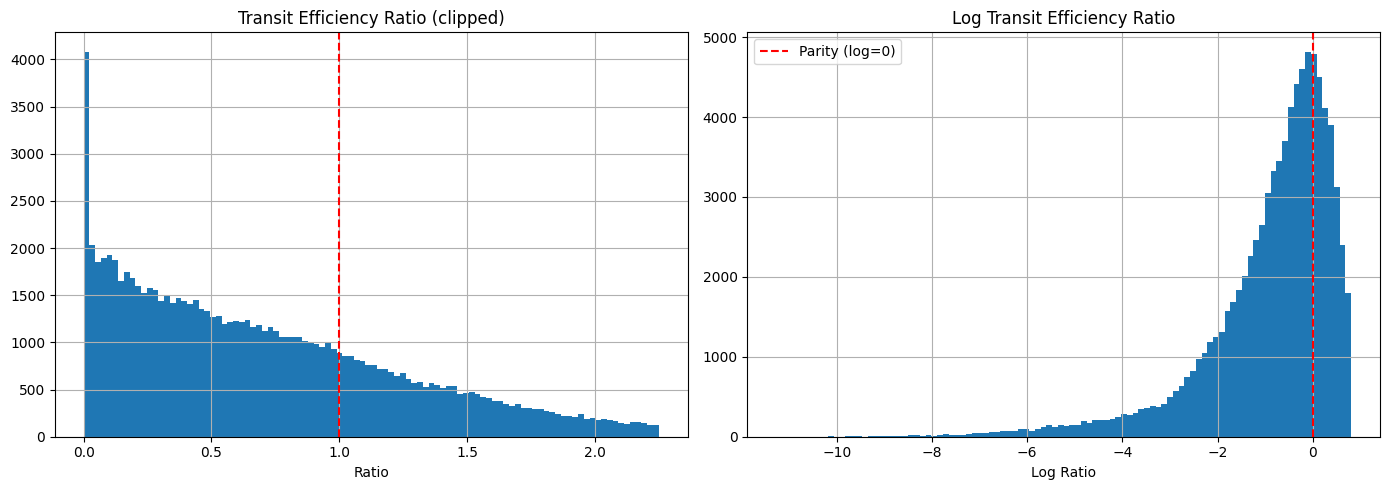

In [34]:
# Check 99th percentile of ratio
q99 = df_analysis['transit_ratio'].quantile(0.99)
q01 = df_analysis['transit_ratio'].quantile(0.01)
print(f"1st percentile: {q01:.3f}")
print(f"99th percentile: {q99:.3f}")

# Clip to 1st-99th percentile range
df_analysis = df_analysis[
    (df_analysis['transit_ratio'] <= q99)
]
print(f"CBGs remaining: {len(df_analysis)}")



# The ratio is right skewed so log transform it
# This will make it more suitable for regression
import numpy as np
df_analysis['transit_ratio_log'] = np.log(df_analysis['transit_ratio'])


print(df_analysis['transit_ratio_log'].describe())

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_analysis['transit_ratio'].clip(0, 3).hist(bins=100, ax=axes[0])


axes[0].set_title('Transit Efficiency Ratio (clipped)')
axes[0].set_xlabel('Ratio')
axes[0].axvline(1, color='red', linestyle='--')

df_analysis['transit_ratio_log'].hist(bins=100, ax=axes[1])
axes[1].set_title('Log Transit Efficiency Ratio')
axes[1].set_xlabel('Log Ratio')
axes[1].axvline(0, color='red', linestyle='--', label='Parity (log=0)')
axes[1].legend()

plt.tight_layout()
plt.show()

Share where transit < 25% of auto access:
0.25666045645086166
Mean transit ratio by density group:
density_group
Low Density     0.561109
High Density    0.830652
Name: transit_ratio, dtype: float64
Mean transit ratio by zero-frequency status:
zero_transit
False    0.69588
Name: transit_ratio, dtype: float64


/tmp/ipykernel_712/3984236826.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_analysis.groupby('density_group')['transit_ratio'].mean())


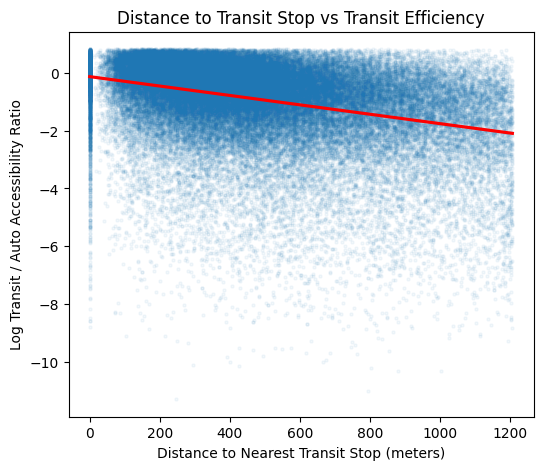

AO0_quartile
0   -1.310116
1   -1.103987
2   -0.837064
3   -0.342740
Name: transit_ratio_log, dtype: float64


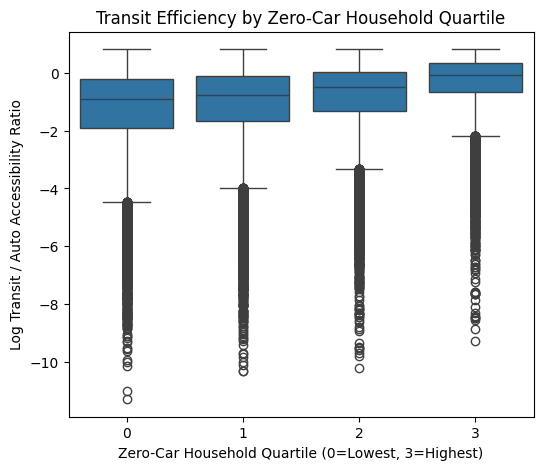

In [35]:

print("Share where transit < 25% of auto access:")
print((df_analysis['transit_ratio'] < 0.25).mean())

df_analysis['density_group'] = pd.qcut(
    df_analysis['D1B'], 2, labels=['Low Density','High Density']
)

print("Mean transit ratio by density group:")
print(df_analysis.groupby('density_group')['transit_ratio'].mean())

print("Mean transit ratio by zero-frequency status:")
print(
    df_analysis.assign(
        zero_transit = df_analysis['D4C'] == 0
    ).groupby('zero_transit')['transit_ratio'].mean()
)

plt.figure(figsize=(6,5))
import seaborn as sns
sns.regplot(
    x='D4A',
    y='transit_ratio_log',
    data=df_analysis,
    scatter_kws={'alpha':0.05, 's':5},
    line_kws={'color':'red'}
)
plt.title("Distance to Transit Stop vs Transit Efficiency")
plt.xlabel("Distance to Nearest Transit Stop (meters)")
plt.ylabel("Log Transit / Auto Accessibility Ratio")
plt.show()

# Create quartiles of zero-car households
df_analysis['AO0_quartile'] = pd.qcut(df_analysis['Pct_AO0'], 4, labels=False)

# Mean transit efficiency by quartile
print(
    df_analysis.groupby('AO0_quartile')['transit_ratio_log'].mean()
)

# Vizualize
plt.figure(figsize=(6,5))
sns.boxplot(
    x='AO0_quartile',
    y='transit_ratio_log',
    data=df_analysis
)
plt.title("Transit Efficiency by Zero-Car Household Quartile")
plt.xlabel("Zero-Car Household Quartile (0=Lowest, 3=Highest)")
plt.ylabel("Log Transit / Auto Accessibility Ratio")
plt.show()

In [36]:
# Save the finalised analysis dataset
df_analysis.to_csv('sld_analysis.csv', index=False)

print("Target variable locked: transit_ratio_log")
print(f"Final dataset: {len(df_analysis)} CBGs")
print("\nInterpretation reminder:")
print("  log ratio = 0  → transit matches auto")
print("  log ratio < 0  → transit underperforms auto (investment opportunity)")
print("  log ratio > 0  → transit outperforms auto (already well served)")

cbsa_mean = (
    df_analysis
    .groupby('CBSA_Name')['transit_ratio_log']
    .mean()
    .sort_values()
)

print("Bottom 10 metros by transit efficiency:")
print(cbsa_mean.head(10))

print("\nTop 10 metros by transit efficiency:")
print(cbsa_mean.tail(10))

# Geographic dispersion (state level)
print("\nState-level dispersion of transit efficiency:")
print(
    df_analysis.groupby('STATEFP')['transit_ratio_log']
    .mean()
    .describe()
)

# High need (AKA above median zero-car + above median low-wage)
df_analysis['high_need'] = (
    (df_analysis['Pct_AO0'] > df_analysis['Pct_AO0'].median()) &
    (df_analysis['R_PCTLOWWAGE'] > df_analysis['R_PCTLOWWAGE'].median())
)

# Low transit efficiency (AKA bottom 20%)
df_analysis['low_transit'] = (
    df_analysis['transit_ratio_log']
    <= df_analysis['transit_ratio_log'].quantile(0.2)
)

# Share of areas that are both
print("Share of high-need areas that are also low-transit:")
print(
    df_analysis[df_analysis['high_need']]['low_transit'].mean()
)


Target variable locked: transit_ratio_log
Final dataset: 85880 CBGs

Interpretation reminder:
  log ratio = 0  → transit matches auto
  log ratio < 0  → transit underperforms auto (investment opportunity)
  log ratio > 0  → transit outperforms auto (already well served)
Bottom 10 metros by transit efficiency:
CBSA_Name
Frankfort, KY                                   -4.077139
Kingsport-Bristol, TN-VA                        -4.040105
Kingston, NY                                    -3.814897
Myrtle Beach-Conway-North Myrtle Beach, SC-NC   -3.804916
Heber, UT                                       -3.476233
Burlington, IA-IL                               -3.189221
Poughkeepsie-Newburgh-Middletown, NY            -3.174012
Toledo, OH                                      -3.053968
Muscatine, IA                                   -3.049073
Fremont, NE                                     -3.043642
Name: transit_ratio_log, dtype: float64

Top 10 metros by transit efficiency:
CBSA_Name
Duluth, MN-

In [37]:
print(f"Number of NaN values in 'transit_ratio_log': {df_analysis['transit_ratio_log'].isna().sum()}")

# Also check other columns related to transit ratio creation
print(f"Number of NaN values in 'transit_ratio': {df_analysis['transit_ratio'].isna().sum()}")
print(f"Number of NaN values in 'D5AR': {df_analysis['D5AR'].isna().sum()}")
print(f"Number of NaN values in 'D5BR': {df_analysis['D5BR'].isna().sum()}")

# Display rows with NaN in transit_ratio_log for inspection if any
if df_analysis['transit_ratio_log'].isna().any():
    print("\nSample rows where 'transit_ratio_log' is NaN:")
    print(df_analysis[df_analysis['transit_ratio_log'].isna()].head())

Number of NaN values in 'transit_ratio_log': 0
Number of NaN values in 'transit_ratio': 0
Number of NaN values in 'D5AR': 0
Number of NaN values in 'D5BR': 0


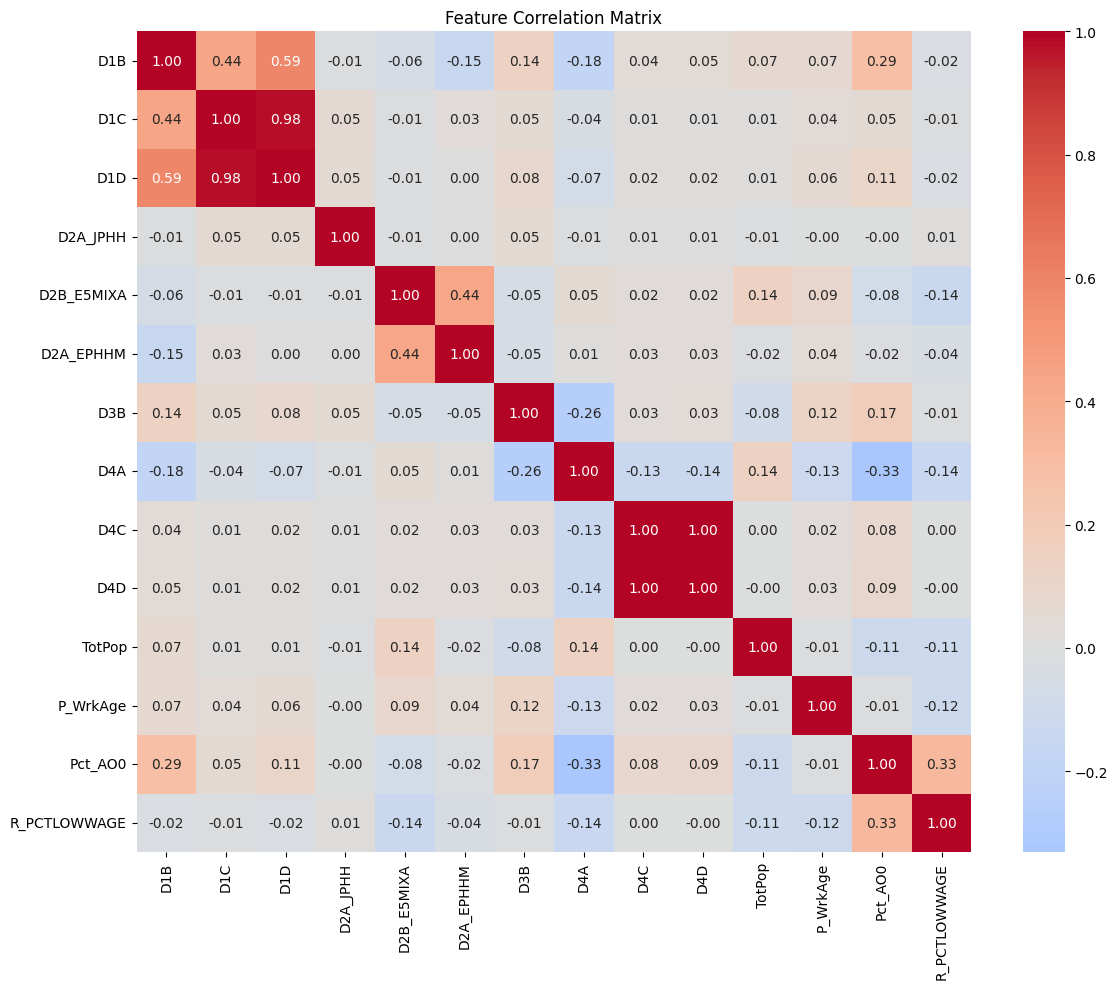

Correlation of features with transit efficiency:
D4A            -0.328663
TotPop         -0.084781
D2B_E5MIXA     -0.027459
D2A_JPHH        0.013227
D2A_EPHHM       0.021635
D1C             0.034616
D1D             0.068141
R_PCTLOWWAGE    0.086080
P_WrkAge        0.122100
D1B             0.163720
D4C             0.179554
D4D             0.183628
D3B             0.215279
Pct_AO0         0.265788
Name: transit_ratio_log, dtype: float64


In [38]:
features = [
    'D1B', 'D1C', 'D1D',
    'D2A_JPHH', 'D2B_E5MIXA', 'D2A_EPHHM',
    'D3B',
    'D4A', 'D4C', 'D4D',
    'TotPop', 'P_WrkAge', 'Pct_AO0', 'R_PCTLOWWAGE'
]

# Check correlations between features to flag multicollinearity
import seaborn as sns

corr = df_analysis[features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("Correlation of features with transit efficiency:")
print(
    df_analysis[features + ['transit_ratio_log']]
    .corr()['transit_ratio_log']
    .drop('transit_ratio_log')
    .sort_values()
)

CBGs remaining after D4A fix: 85880

Skewness after transformation:
D2A_JPHH_log    2.477763
Pct_AO0         1.967251
D1C_log         1.222624
R_PCTLOWWAGE    0.832167
D4A             0.621516
D4C_log         0.589208
D4D_log         0.529580
D1B_log         0.293242
P_WrkAge        0.063729
D2A_EPHHM      -0.129535
TotPop_log     -0.470824
D2B_E5MIXA     -0.562874
D3B_log        -1.451329
dtype: float64


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


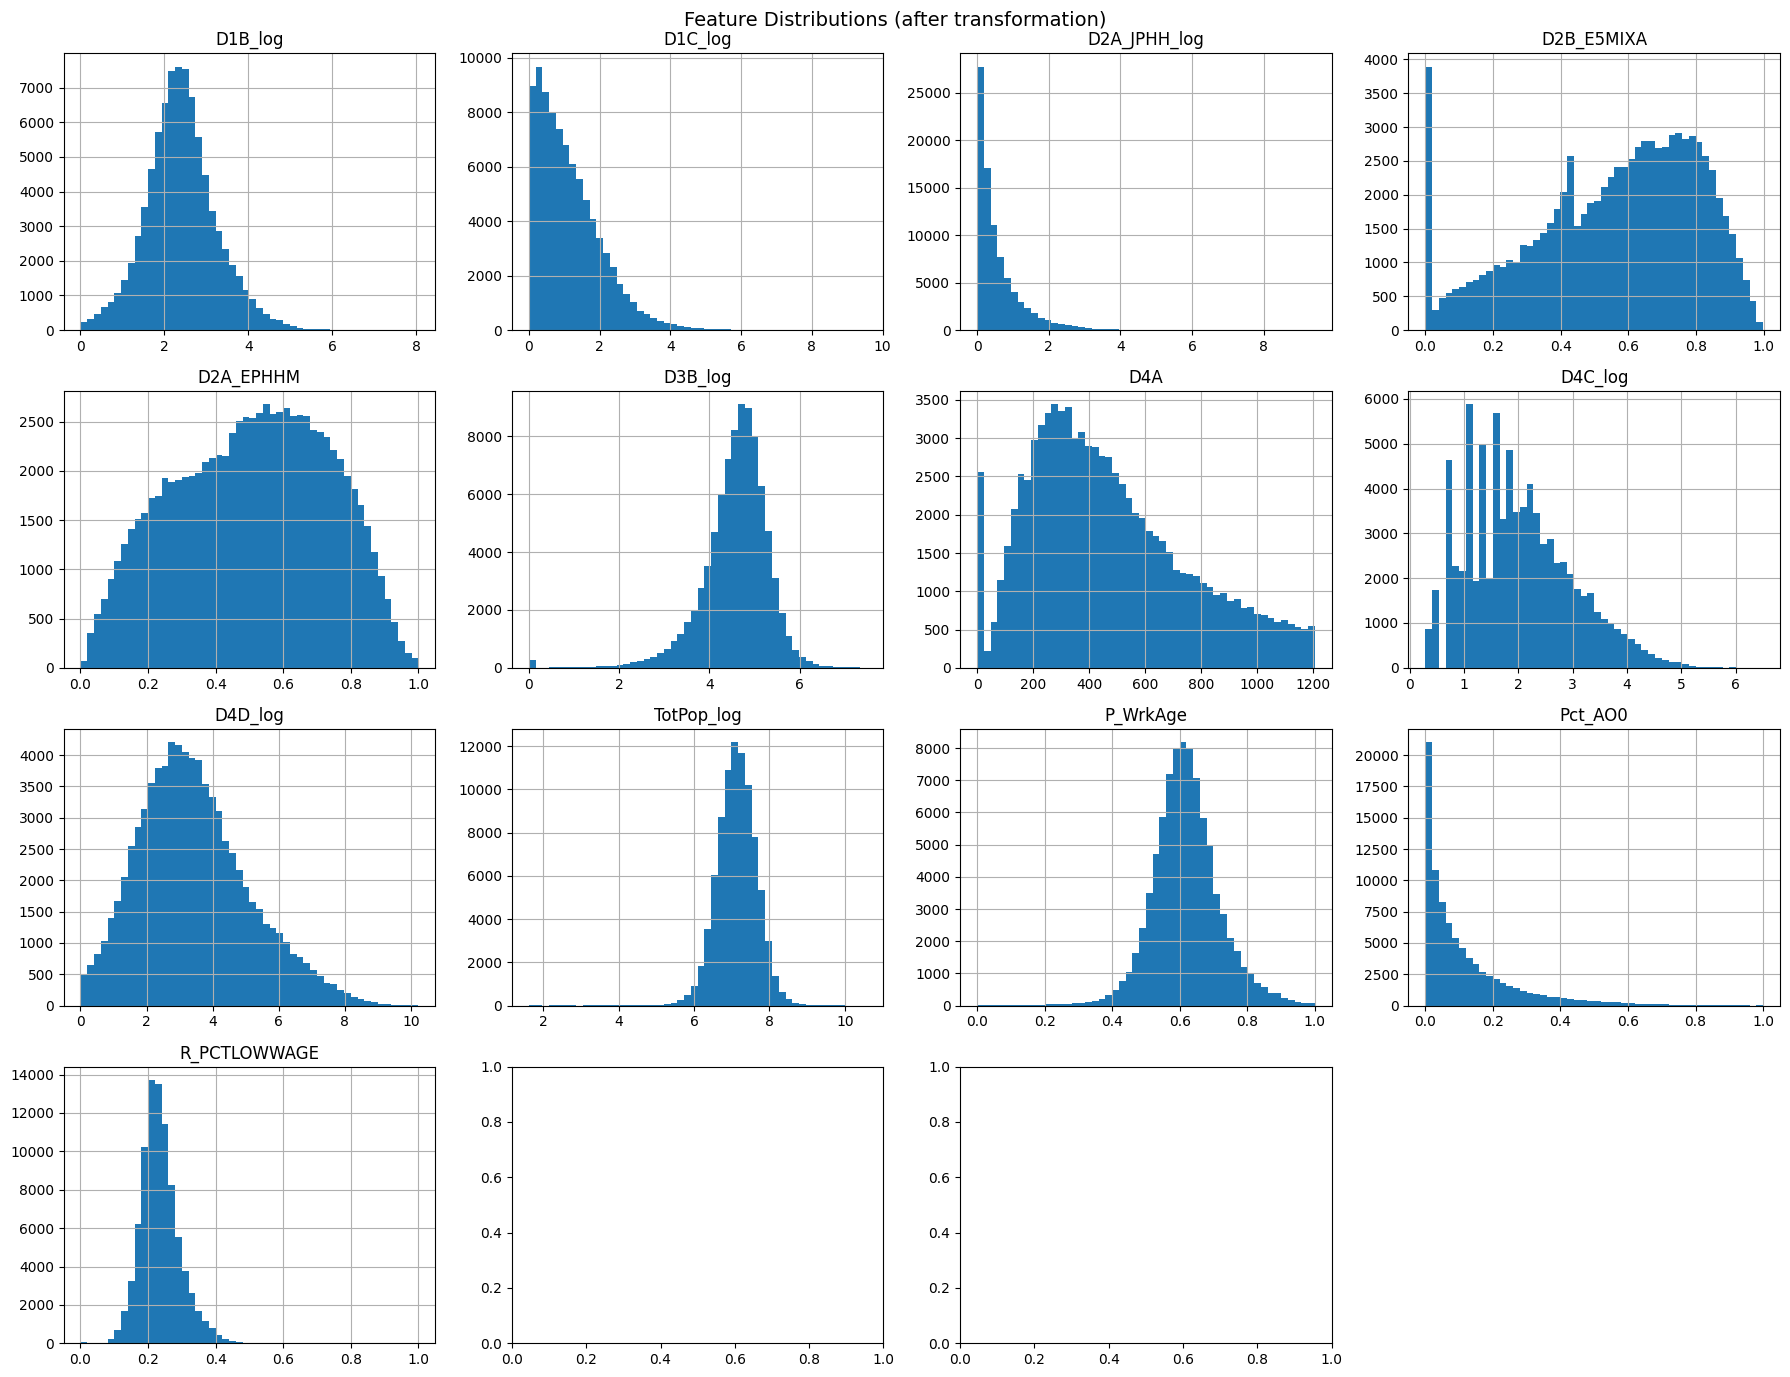

In [39]:
# Fix D4A sentinel values first
df_analysis = df_analysis[df_analysis['D4A'] >= 0]
print(f"CBGs remaining after D4A fix: {len(df_analysis)}")

# Log transform skewed features
# Adding 1 before log to handle any zero values
skewed_features = ['D1B', 'D1C', 'D2A_JPHH', 'D4C', 'D4D', 'TotPop', 'D3B']

for feat in skewed_features:
    df_analysis[f'{feat}_log'] = np.log1p(df_analysis[feat])

# Update features list - replace originals with log versions
features = [
    'D1B_log', 'D1C_log',
    'D2A_JPHH_log', 'D2B_E5MIXA', 'D2A_EPHHM',
    'D3B_log',
    'D4A', 'D4C_log', 'D4D_log',
    'TotPop_log', 'P_WrkAge', 'Pct_AO0', 'R_PCTLOWWAGE'
]

# Check skewness again
print("\nSkewness after transformation:")
print(df_analysis[features].skew().sort_values(ascending=False))

# Replot distributions
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, feature in enumerate(features):
    df_analysis[feature].hist(bins=50, ax=axes[i])
    axes[i].set_title(feature)

axes[-1].set_visible(False)
plt.suptitle('Feature Distributions (after transformation)', fontsize=14)
plt.tight_layout()
plt.show()

Final skewness:
D2A_JPHH_log    2.477763
Pct_AO0         1.967251
D1C_log         1.222624
R_PCTLOWWAGE    0.832167
D4A             0.621516
D4C_log         0.589208
D4D_log         0.529580
D1B_log         0.293242
P_WrkAge        0.063729
D2A_EPHHM      -0.129535
TotPop_log     -0.470824
D2B_E5MIXA     -0.562874
D3B_log        -1.451329
dtype: float64


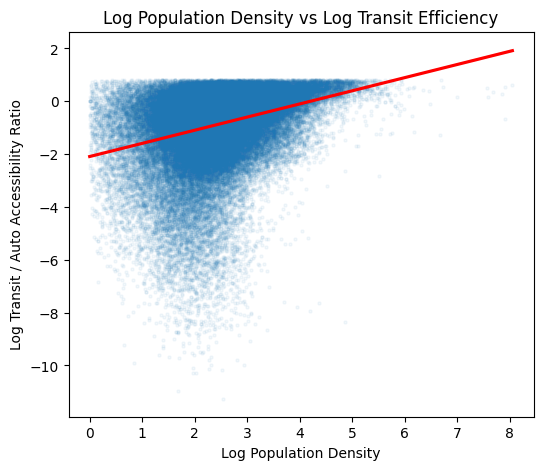

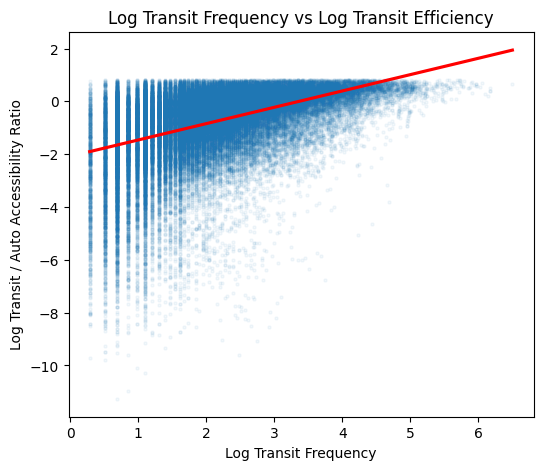

In [41]:


# Update features list
features = [
    'D1B_log', 'D1C_log',
    'D2A_JPHH_log', 'D2B_E5MIXA', 'D2A_EPHHM',
    'D3B_log',
    'D4A', 'D4C_log', 'D4D_log',
    'TotPop_log', 'P_WrkAge', 'Pct_AO0', 'R_PCTLOWWAGE'
]

# Check skewness
print("Final skewness:")
print(df_analysis[features].skew().sort_values(ascending=False))

plt.figure(figsize=(6,5))
sns.regplot(
    x='D1B_log',
    y='transit_ratio_log',
    data=df_analysis,
    scatter_kws={'alpha':0.05, 's':5},
    line_kws={'color':'red'}
)
plt.title("Log Population Density vs Log Transit Efficiency")
plt.xlabel("Log Population Density")
plt.ylabel("Log Transit / Auto Accessibility Ratio")
plt.show()

plt.figure(figsize=(6,5))
sns.regplot(
    x='D4C_log',
    y='transit_ratio_log',
    data=df_analysis,
    scatter_kws={'alpha':0.05, 's':5},
    line_kws={'color':'red'}
)
plt.title("Log Transit Frequency vs Log Transit Efficiency")
plt.xlabel("Log Transit Frequency")
plt.ylabel("Log Transit / Auto Accessibility Ratio")
plt.show()

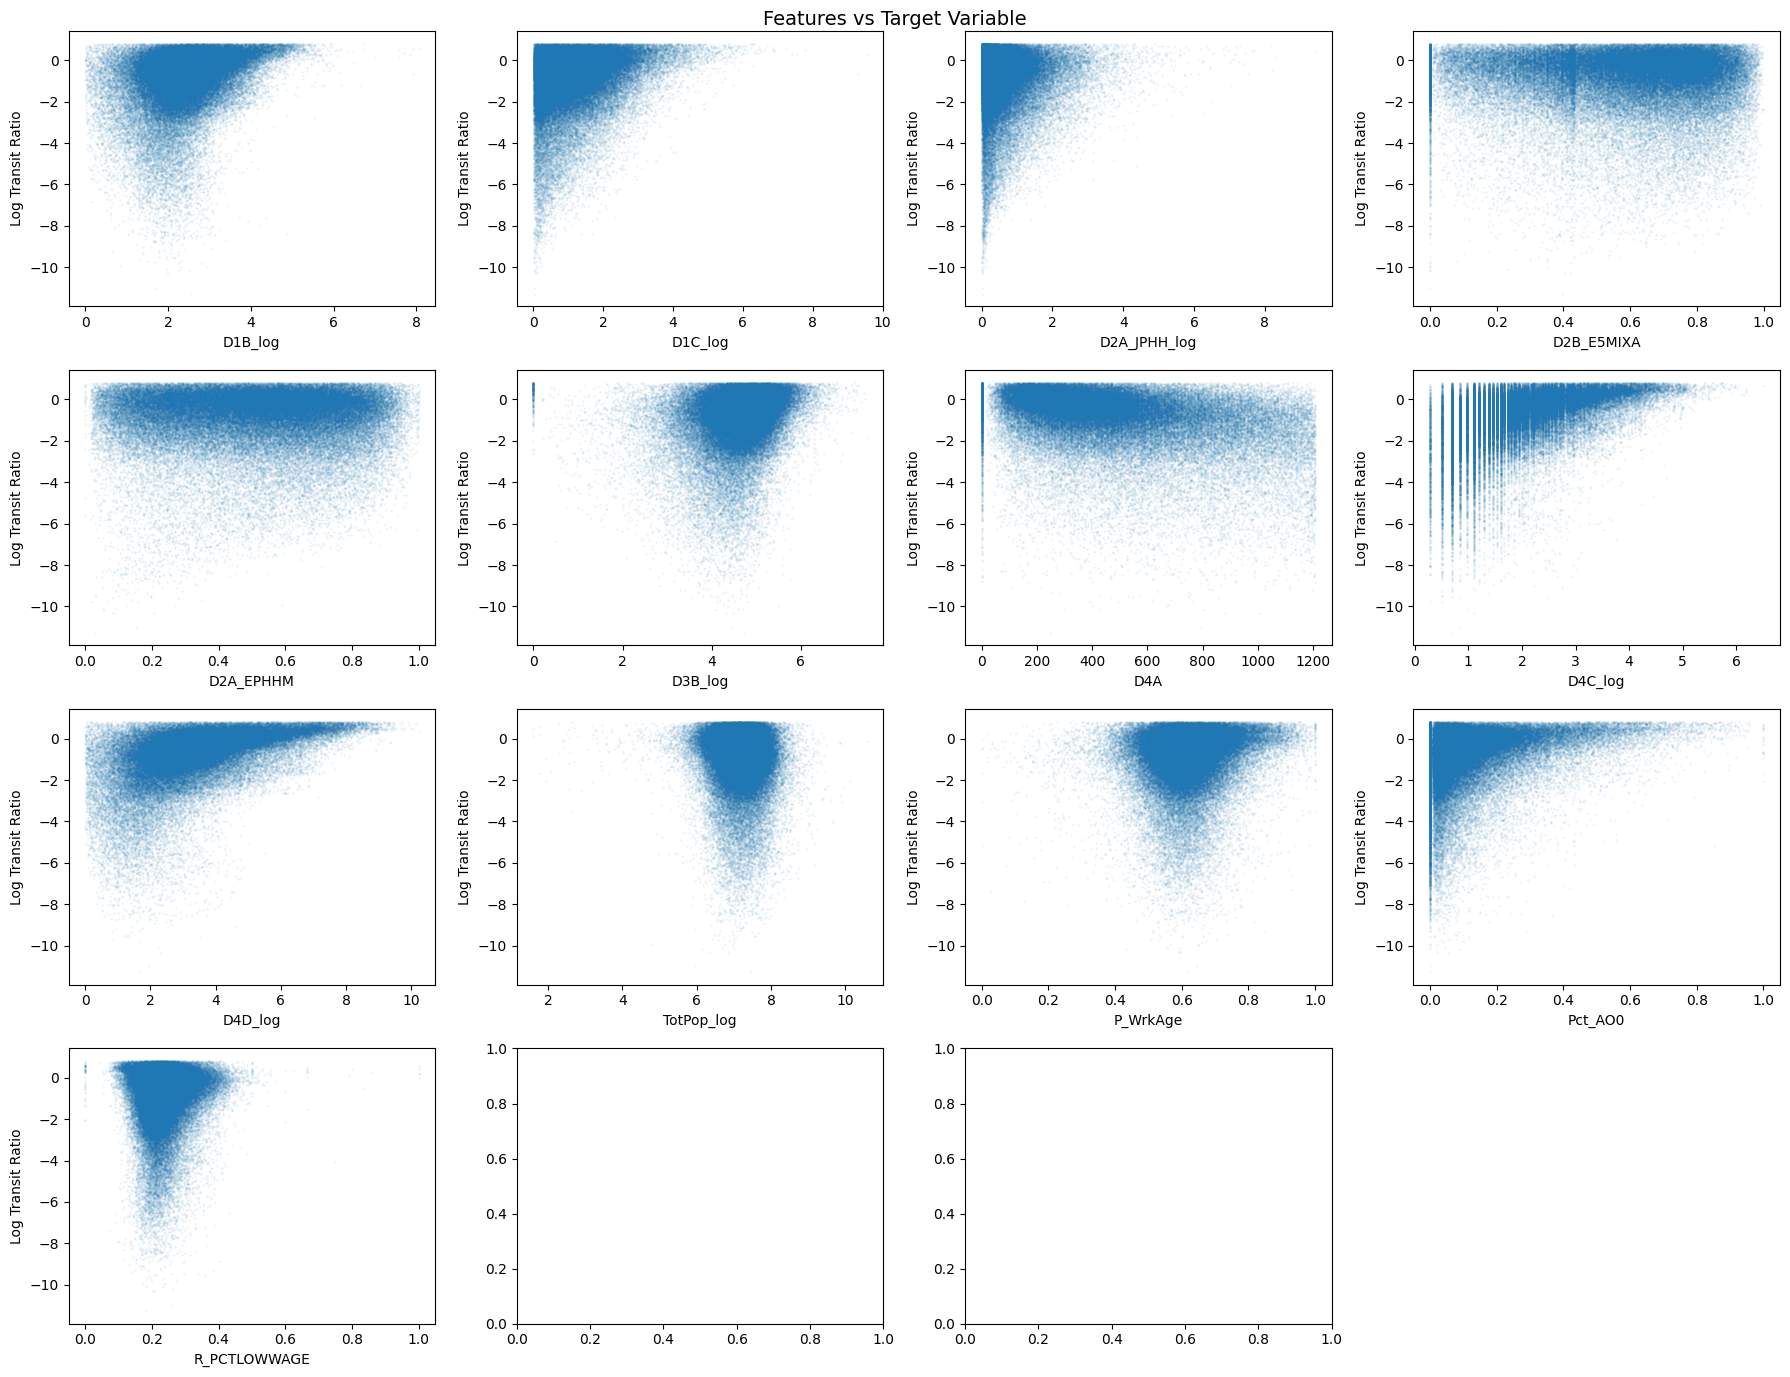

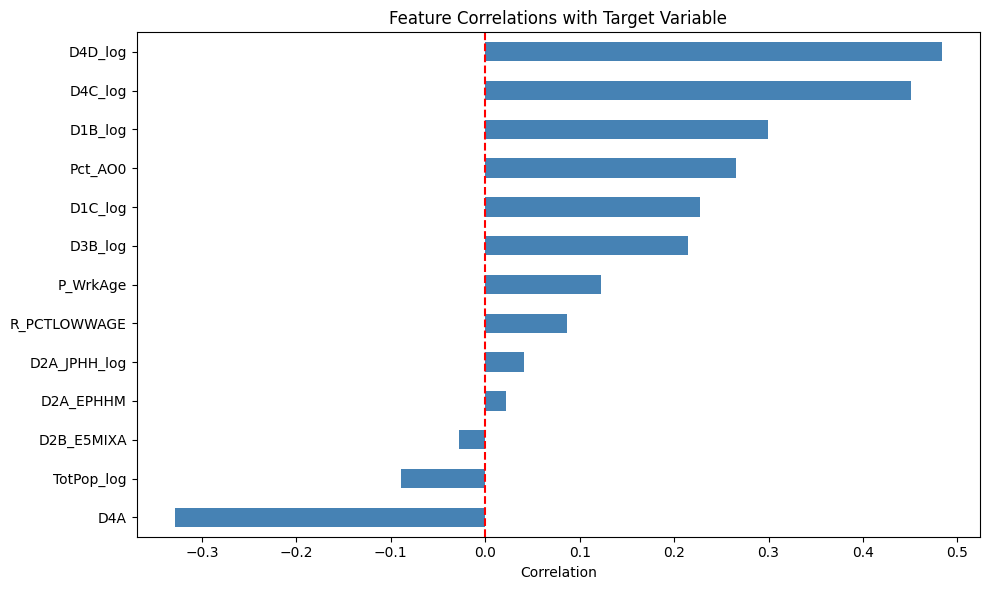

D4A            -0.328663
TotPop_log     -0.089141
D2B_E5MIXA     -0.027459
D2A_EPHHM       0.021635
D2A_JPHH_log    0.040972
R_PCTLOWWAGE    0.086080
P_WrkAge        0.122100
D3B_log         0.215094
D1C_log         0.227641
Pct_AO0         0.265788
D1B_log         0.299413
D4C_log         0.450790
D4D_log         0.483381
Name: transit_ratio_log, dtype: float64


In [42]:
# Step 2: Scatter plots against target
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(
        df_analysis[feature],
        df_analysis['transit_ratio_log'],
        alpha=0.05, s=1
    )
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Log Transit Ratio')

axes[-1].set_visible(False)
plt.suptitle('Features vs Target Variable', fontsize=14)
plt.tight_layout()
plt.show()

# Step 3: Correlation with target
target_corr = df_analysis[features + ['transit_ratio_log']]\
    .corr()['transit_ratio_log']\
    .drop('transit_ratio_log')\
    .sort_values()

target_corr.plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.axvline(0, color='red', linestyle='--')
plt.title('Feature Correlations with Target Variable')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

print(target_corr)

Using rows: 80005
Train R^2: 0.5796040009651866
Test  R^2: 0.30645703380829137
Note: Baseline model (predicting mean) has R^2 = 0


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Top 15 most important features (permutation importance):
D4D_log         0.266931
D4C_log         0.060727
D4A             0.032919
R_PCTLOWWAGE    0.027345
P_WrkAge        0.005016
D3B_log         0.003922
D2A_JPHH_log    0.003874
D1B_log         0.002977
D1C_log         0.002589
Pct_AO0         0.001574
D2B_E5MIXA      0.000981
TotPop_log      0.000964
D2A_EPHHM       0.000470
dtype: float64


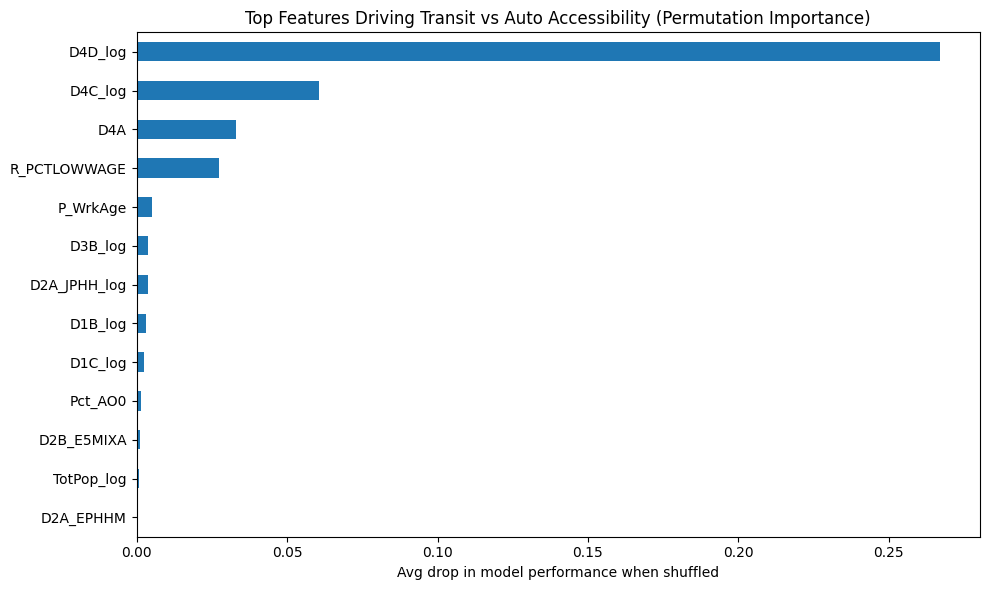

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# Pick X (features) and y (target)
X = df_analysis[features].replace([np.inf, -np.inf], np.nan)
y = df_analysis['transit_ratio_log']

# Drop rows missing any feature/target values
keep_idx = X.dropna().index.intersection(y.dropna().index)
X = X.loc[keep_idx]
y = y.loc[keep_idx]
print("Using rows:", len(X))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10
)

# Fit baseline model
rf = RandomForestRegressor(
    n_estimators=250,
    random_state=10,
    n_jobs=-1,
    min_samples_leaf=10
)
rf.fit(X_train, y_train)

print("Train R^2:", rf.score(X_train, y_train))
print("Test  R^2:", rf.score(X_test, y_test))
print("Note: Baseline model (predicting mean) has R^2 = 0")

# Permutation importance on the test set
perm = permutation_importance(
    rf, X_test, y_test,
    n_repeats=10,
    random_state=10,
    n_jobs=-1
)
importance = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

print("\nTop 15 most important features (permutation importance):")
print(importance.head(15))

# Plot top 15
top15 = importance.head(15).sort_values()

plt.figure(figsize=(10, 6))
top15.plot(kind="barh")
plt.title("Top Features Driving Transit vs Auto Accessibility (Permutation Importance)")
plt.xlabel("Avg drop in model performance when shuffled")
plt.tight_layout()
plt.show()

Features scaled successfully
Shape: (80005, 13)
k=2 done
k=3 done
k=4 done
k=5 done
k=6 done
k=7 done
k=8 done
k=9 done
k=10 done


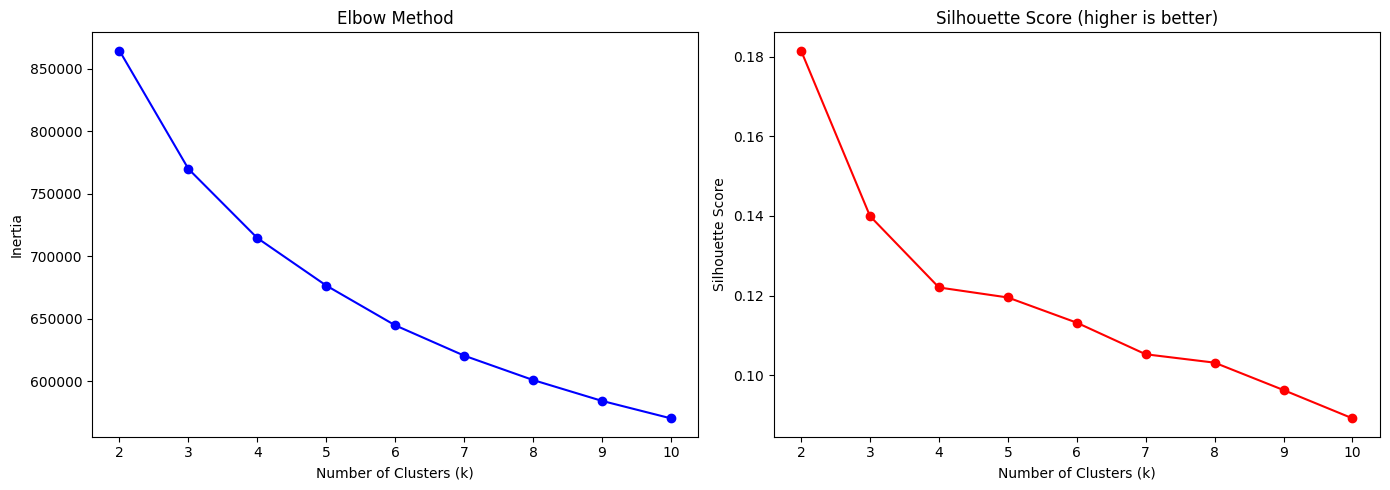

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Scale features first
# Clustering is distance-based so scaling is essential
scaler = StandardScaler()
Xc = df_analysis[features].replace([np.inf, -np.inf], np.nan).dropna()
df_analysis = df_analysis.loc[Xc.index].copy()

X_scaled = scaler.fit_transform(Xc)

#
# X_scaled = scaler.fit_transform(df_analysis[features])

print("Features scaled successfully")
print(f"Shape: {X_scaled.shape}")

# Step 2: Find optimal number of clusters using elbow method
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_, sample_size=10000))
    print(f"k={k} done")

# Step 3: Plot both metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(k_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (higher is better)')

plt.tight_layout()
plt.show()

In [ ]:
# Fit final clustering model with k=5
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
df_analysis['cluster'] = kmeans_final.fit_predict(X_scaled)

# Check cluster sizes
print("Cluster sizes:")
print(df_analysis['cluster'].value_counts().sort_index())

# Check mean feature values per cluster
cluster_profiles = df_analysis[features + ['cluster']].groupby('cluster').mean()
print("\nCluster profiles:")
print(cluster_profiles.round(3))

Cluster sizes:
cluster
0    19055
1    31280
2    17064
3    12641
4     6182
Name: count, dtype: int64

Cluster profiles:
         D1B_log  D1C_log  D3B_log      D4A  D4C_log  D4D_log  TotPop_log  \
cluster                                                                     
0          1.679    0.796    3.969  791.276    1.363    1.788       7.285   
1          2.428    1.002    4.706  428.307    1.694    3.030       7.203   
2          3.057    1.827    5.032  282.881    3.052    5.271       7.127   
3          2.279    1.002    4.728  307.945    2.141    3.846       6.696   
4          4.417    2.736    4.182  203.397    4.098    7.735       7.164   

         P_WrkAge  Pct_AO0_log  R_PCTLOWWAGE  
cluster                                       
0           0.588        0.052         0.228  
1           0.617        0.055         0.218  
2           0.681        0.138         0.214  
3           0.587        0.213         0.319  
4           0.655        0.446         0.218  
